# Predicting Employee Attrition Using Machine Learning

**Author:** Katherine Geller  
**Date:** May 2026  
**Course:** Data Science Capstone (Project 2)

---

## BLUF (Bottom Line Up Front)

Employee turnover is super expensive. Every time someone leaves, the company has to spend money recruiting, hiring, and training a replacement. For HR teams, the real challenge is figuring out **who is at risk of leaving BEFORE they actually leave**, so they can step in with retention strategies.

In this project, I built a machine learning model that predicts whether an employee is likely to leave the company, using the IBM HR Analytics Employee Attrition dataset (1,470 employees, 35 features).

**Final results:**
- Best model: **Logistic Regression** (after hyperparameter tuning)
- ROC-AUC on test set: **0.80**
- Recall on the "leaves" class: **0.68** (we catch about 68% of employees who actually leave)
- Top drivers of attrition: **OverTime, BusinessTravel (frequent), JobRole (Lab Tech, Sales Rep), MaritalStatus (Single), YearsSinceLastPromotion**

The full scikit-learn pipeline (preprocessing + model) is saved as a pickle file (`final_attrition_pipeline.pkl`) so it can be loaded and used to score new employees later.

---

## Project Structure (CRISP-DM)

I'm following the CRISP-DM framework that we learned in class:

1. **Business Understanding** - what are we trying to solve?
2. **Data Understanding** - explore the data (EDA)
3. **Data Preparation** - clean it up, encode categoricals, scale numerics
4. **Modeling** - try Logistic Regression, Decision Tree, Random Forest
5. **Evaluation** - compare models, pick the best one, evaluate on test set
6. **Deployment** - save the pipeline as a pickle file so it can be reused

---

## 1. Business Understanding

**Problem:** Predict which employees are likely to leave the company so HR can intervene early.

**Stakeholders:**
- HR leadership (wants lower turnover costs)
- Department managers (wants to know who on their team is a flight risk)
- Executive leadership (cares about retention rates and cost savings)

**Why ML?** With 35 features per employee, it is just too much for a person to manually look at and weigh. ML can find patterns and combinations of factors that predict attrition.

**Success metric:** I'm using ROC-AUC as my main metric because the data is imbalanced (only about 16% of employees actually leave). I also care a lot about **recall** because missing an at-risk employee (false negative) is more costly than a false alarm (false positive).

## 2. Setup and Imports

Loading all the libraries I need for this project. I'm using pandas for data, matplotlib and seaborn for plots, and scikit-learn for the modeling.

In [1]:
# Import libraries for data and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Import sklearn stuff for modeling
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Ignore warnings so the notebook is cleaner
import warnings
warnings.filterwarnings("ignore")

print("All libraries loaded")

All libraries loaded


## 3. Data Understanding (EDA)

### 3.1 Load the dataset

The dataset is from Kaggle (IBM HR Analytics Employee Attrition & Performance). The CSV is in the same folder as the notebook.

In [2]:
# Load the data
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Print the shape so I know how big the dataset is
print("Shape:", df.shape)

# Show the first 5 rows
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### 3.2 Basic info about the data

Let me check the data types and see if there are any missing values.

In [3]:
# .info() shows me the data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

Missing values per column:
0 total missing values


Cool, there are no missing values. That makes my life a lot easier since I don't need to worry about imputation.

In [5]:
# Get summary statistics for the numeric columns
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### 3.3 Look at the target variable

The target is `Attrition` which is "Yes" (left the company) or "No" (still employed).

In [6]:
# Count how many of each class
print(df["Attrition"].value_counts())
print()
print(df["Attrition"].value_counts(normalize=True))

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


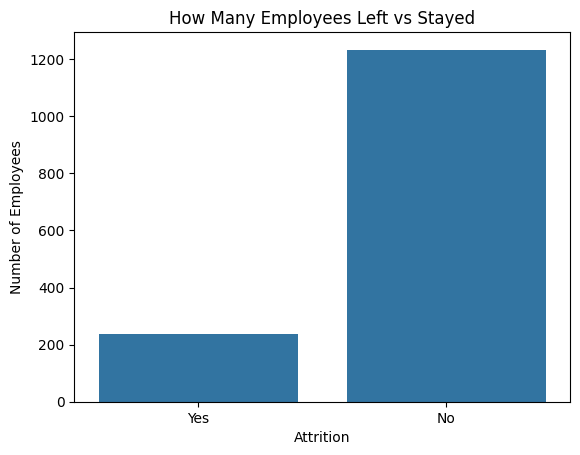

In [7]:
# Make a simple bar chart of the class distribution
sns.countplot(data=df, x="Attrition")
plt.title("How Many Employees Left vs Stayed")
plt.ylabel("Number of Employees")
plt.savefig("images/01_attrition_distribution.png")
plt.show()

So about **16% of employees in the dataset left the company**, and 84% stayed. This is a pretty imbalanced dataset, which is something I will need to handle later when I train the models. If I just predicted "No" for everyone, I'd get 84% accuracy but that wouldn't actually help anyone. That's why I'm using ROC-AUC and recall as my main metrics instead of plain accuracy.

### 3.4 Explore numeric features

Let me look at how some of the key numeric features differ between people who left vs stayed. I'll just plot a few I think are interesting one at a time.

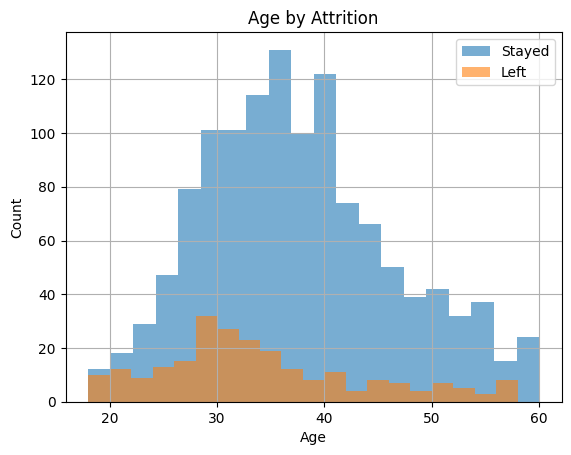

In [8]:
# Age
df[df["Attrition"] == "No"]["Age"].hist(bins=20, alpha=0.6, label="Stayed")
df[df["Attrition"] == "Yes"]["Age"].hist(bins=20, alpha=0.6, label="Left")
plt.title("Age by Attrition")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.savefig("images/02a_age_by_attrition.png")
plt.show()

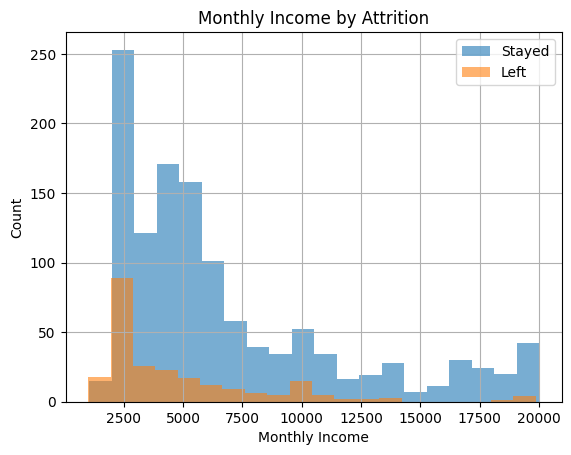

In [9]:
# Monthly Income
df[df["Attrition"] == "No"]["MonthlyIncome"].hist(bins=20, alpha=0.6, label="Stayed")
df[df["Attrition"] == "Yes"]["MonthlyIncome"].hist(bins=20, alpha=0.6, label="Left")
plt.title("Monthly Income by Attrition")
plt.xlabel("Monthly Income")
plt.ylabel("Count")
plt.legend()
plt.savefig("images/02b_income_by_attrition.png")
plt.show()

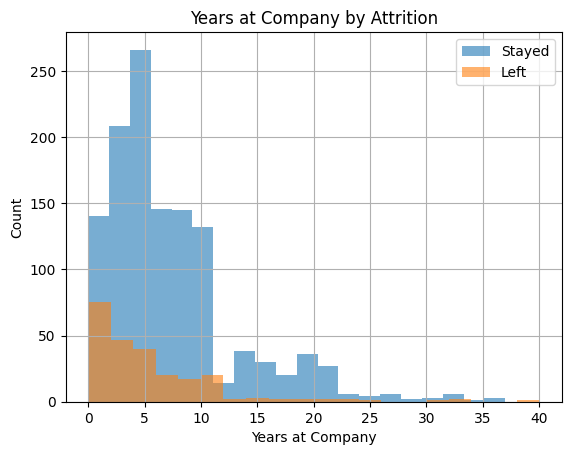

In [10]:
# Years at Company
df[df["Attrition"] == "No"]["YearsAtCompany"].hist(bins=20, alpha=0.6, label="Stayed")
df[df["Attrition"] == "Yes"]["YearsAtCompany"].hist(bins=20, alpha=0.6, label="Left")
plt.title("Years at Company by Attrition")
plt.xlabel("Years at Company")
plt.ylabel("Count")
plt.legend()
plt.savefig("images/02c_yearsatcompany_by_attrition.png")
plt.show()

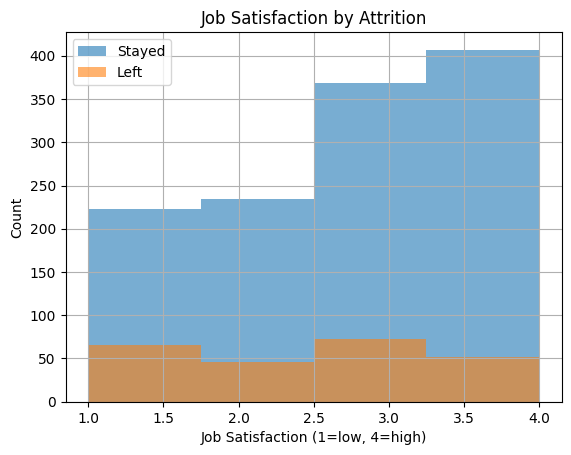

In [11]:
# Job Satisfaction
df[df["Attrition"] == "No"]["JobSatisfaction"].hist(bins=4, alpha=0.6, label="Stayed")
df[df["Attrition"] == "Yes"]["JobSatisfaction"].hist(bins=4, alpha=0.6, label="Left")
plt.title("Job Satisfaction by Attrition")
plt.xlabel("Job Satisfaction (1=low, 4=high)")
plt.ylabel("Count")
plt.legend()
plt.savefig("images/02d_jobsatisfaction_by_attrition.png")
plt.show()

**My observations:**
- People who left tend to be **younger** (more in the 20-30 range)
- People who left tend to have **lower MonthlyIncome**
- People who left tend to have **fewer YearsAtCompany** (newer employees leave more)
- **JobSatisfaction** seems like it could be a predictor too, with more "1"s and "2"s in the leavers group

These all kind of make sense intuitively, which is a good sign that the data is reasonable.

### 3.5 Explore categorical features

Now let me look at how attrition rates differ across different categories. I'll do these one at a time too.

Attrition         No        Yes
OverTime                       
No         89.563567  10.436433
Yes        69.471154  30.528846


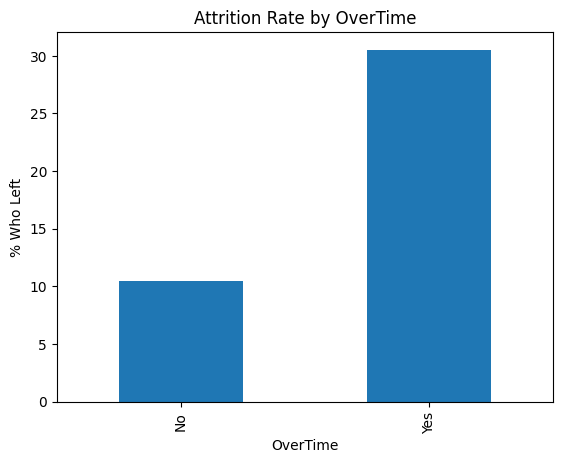

In [12]:
# OverTime - I'm guessing this matters a lot
overtime_table = pd.crosstab(df["OverTime"], df["Attrition"], normalize="index") * 100
print(overtime_table)
overtime_table["Yes"].plot(kind="bar")
plt.title("Attrition Rate by OverTime")
plt.ylabel("% Who Left")
plt.savefig("images/03a_overtime_attrition.png")
plt.show()

Attrition                 No        Yes
BusinessTravel                         
Non-Travel         92.000000   8.000000
Travel_Frequently  75.090253  24.909747
Travel_Rarely      85.043145  14.956855


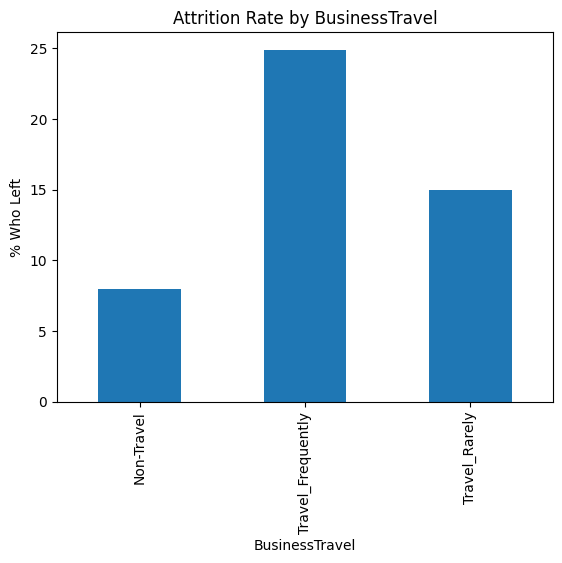

In [13]:
# BusinessTravel
travel_table = pd.crosstab(df["BusinessTravel"], df["Attrition"], normalize="index") * 100
print(travel_table)
travel_table["Yes"].plot(kind="bar")
plt.title("Attrition Rate by BusinessTravel")
plt.ylabel("% Who Left")
plt.savefig("images/03b_businesstravel_attrition.png")
plt.show()

Attrition                         No        Yes
JobRole                                        
Sales Representative       60.240964  39.759036
Laboratory Technician      76.061776  23.938224
Human Resources            76.923077  23.076923
Sales Executive            82.515337  17.484663
Research Scientist         83.904110  16.095890
Manufacturing Director     93.103448   6.896552
Healthcare Representative  93.129771   6.870229
Manager                    95.098039   4.901961
Research Director          97.500000   2.500000


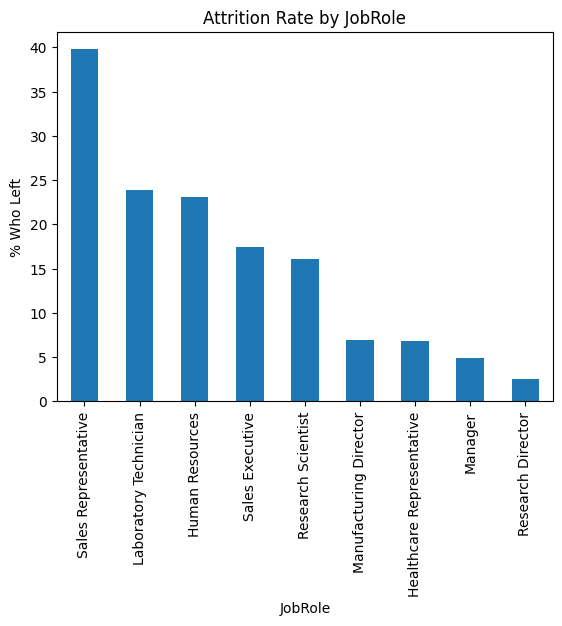

In [14]:
# JobRole
role_table = pd.crosstab(df["JobRole"], df["Attrition"], normalize="index") * 100
role_table = role_table.sort_values("Yes", ascending=False)
print(role_table)
role_table["Yes"].plot(kind="bar")
plt.title("Attrition Rate by JobRole")
plt.ylabel("% Who Left")
plt.savefig("images/03c_jobrole_attrition.png")
plt.show()

Attrition             No        Yes
MaritalStatus                      
Divorced       89.908257  10.091743
Married        87.518574  12.481426
Single         74.468085  25.531915


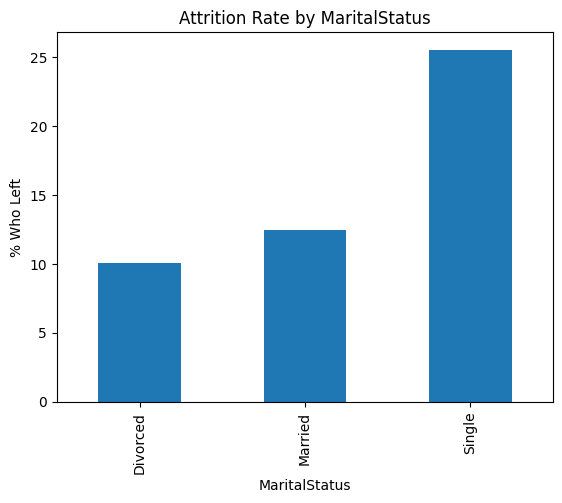

In [15]:
# MaritalStatus
marital_table = pd.crosstab(df["MaritalStatus"], df["Attrition"], normalize="index") * 100
print(marital_table)
marital_table["Yes"].plot(kind="bar")
plt.title("Attrition Rate by MaritalStatus")
plt.ylabel("% Who Left")
plt.savefig("images/03d_maritalstatus_attrition.png")
plt.show()

**My observations:**
- **OverTime = Yes** has a HUGE attrition rate (around 30%), almost double the overall average. This is probably one of the most important features.
- **BusinessTravel = Travel_Frequently** also has higher attrition
- **Sales Representative** has the highest attrition by job role (around 40%)
- **Single** marital status has higher attrition than Married or Divorced

These give me good intuition about what the model might find important.

### 3.6 Correlation heatmap

Let me see which numeric features are correlated with each other (and with attrition once I convert it to numeric).

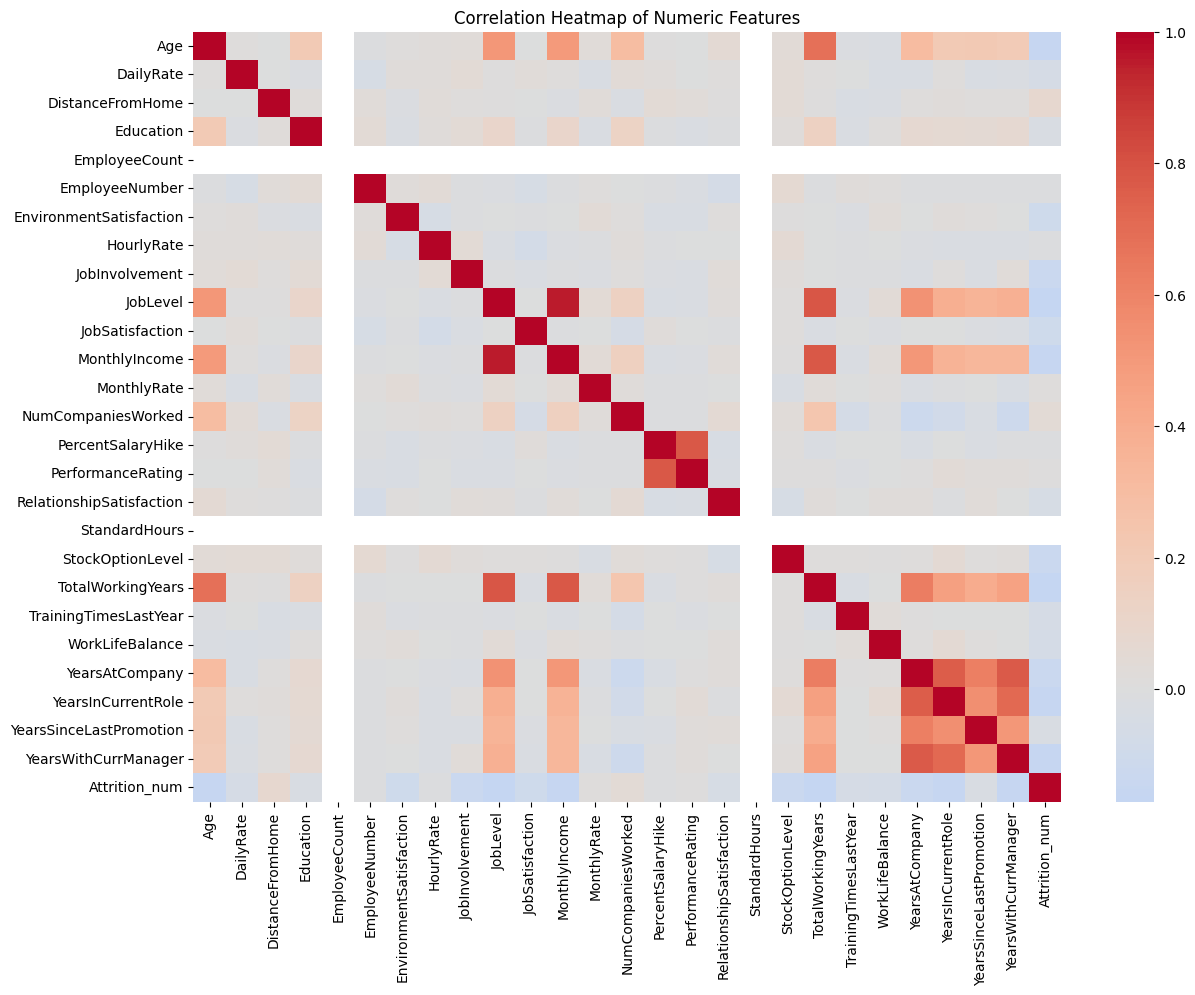

In [16]:
# Make a copy so I don't mess up the original
df_corr = df.copy()
# Convert Attrition to 1/0 for the correlation calculation
df_corr["Attrition_num"] = (df_corr["Attrition"] == "Yes").astype(int)

# Get just the numeric columns
df_numeric = df_corr.select_dtypes(include="number")

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_numeric.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.savefig("images/04_correlation_heatmap.png")
plt.show()

In [17]:
# Print the top correlations with Attrition
attrition_corr = df_numeric.corr()["Attrition_num"]
attrition_corr = attrition_corr.drop("Attrition_num")
# Sort by absolute value to find biggest correlations either way
attrition_corr_sorted = attrition_corr.abs().sort_values(ascending=False)
print("Top 10 features most correlated with Attrition:")
print(attrition_corr_sorted.head(10))

Top 10 features most correlated with Attrition:
TotalWorkingYears       0.171063
JobLevel                0.169105
YearsInCurrentRole      0.160545
MonthlyIncome           0.159840
Age                     0.159205
YearsWithCurrManager    0.156199
StockOptionLevel        0.137145
YearsAtCompany          0.134392
JobInvolvement          0.130016
JobSatisfaction         0.103481
Name: Attrition_num, dtype: float64


The numeric features don't have super strong correlations with Attrition (the strongest is around -0.17). That's actually fine because the categorical features (especially OverTime) are probably where the real signal is.

I also notice that some features are heavily correlated with each other:
- TotalWorkingYears and Age (makes sense, older people have worked longer)
- YearsAtCompany and YearsInCurrentRole (also makes sense)

I won't drop these since tree-based models like Random Forest can handle correlated features fine.

## 4. Data Preparation

Now I need to clean up the data and get it ready for modeling.

### 4.1 Drop useless columns

Some columns have only one unique value, so they can't possibly help the model:
- `EmployeeCount` is always 1
- `Over18` is always "Y"
- `StandardHours` is always 80

Also dropping `EmployeeNumber` because it is just an ID number, not a real feature.

In [18]:
# Check unique values for the columns I think are useless
print("EmployeeCount unique:", df["EmployeeCount"].unique())
print("Over18 unique:", df["Over18"].unique())
print("StandardHours unique:", df["StandardHours"].unique())

EmployeeCount unique: [1]
Over18 unique: <StringArray>
['Y']
Length: 1, dtype: str
StandardHours unique: [80]


In [19]:
# Drop the useless columns
df_clean = df.drop(columns=["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"])
print("Original shape:", df.shape)
print("After dropping useless columns:", df_clean.shape)

Original shape: (1470, 35)
After dropping useless columns: (1470, 31)


### 4.2 Convert target to binary numeric

The target is "Yes"/"No" strings. I need to convert it to 1/0 for the models.

In [20]:
# Convert Attrition: Yes -> 1, No -> 0
df_clean["Attrition"] = (df_clean["Attrition"] == "Yes").astype(int)

# Double check it worked
print(df_clean["Attrition"].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


### 4.3 Identify numeric vs categorical features

I need to split the features into two groups so I can apply different preprocessing to each:
- **Numeric features** -> StandardScaler (so they're all on the same scale)
- **Categorical features** -> OneHotEncoder (so the model can use them)

Some features look numeric (like JobSatisfaction with values 1-4) but are actually ordinal categories. I'll keep those as numeric since they're already in a sensible order.

In [21]:
# Separate features (X) and target (y)
X = df_clean.drop(columns=["Attrition"])
y = df_clean["Attrition"]

# Identify which columns are categorical (object/string) vs numeric
categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(include="number").columns.tolist()

print("Total features:", X.shape[1])
print()
print("Categorical features:", len(categorical_features))
print(categorical_features)
print()
print("Numeric features:", len(numeric_features))
print(numeric_features)

Total features: 30

Categorical features: 7
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numeric features: 23
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


### 4.4 Train/test split

Splitting 80/20 with stratification so the class balance stays the same in train and test.

In [22]:
# Stratified split so the train and test sets have the same % of attrition
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Train attrition rate:", y_train.mean())
print("Test attrition rate:", y_test.mean())

X_train shape: (1176, 30)
X_test shape: (294, 30)
Train attrition rate: 0.16156462585034015
Test attrition rate: 0.1598639455782313


Good, the attrition rate is basically the same in both (around 16%), so stratification worked.

## 5. Build the scikit-learn Pipeline

This is one of the main requirements of the project. I'm building a Pipeline that handles all the preprocessing and modeling in one object. The big benefit is that it makes my code reproducible AND it prevents data leakage (the scaler only sees the training data).

### 5.1 Build the preprocessor with ColumnTransformer

ColumnTransformer lets me apply different transformations to different columns. I'm using:
- StandardScaler on numeric columns
- OneHotEncoder on categorical columns (with `handle_unknown='ignore'` so it doesn't break if it sees a new category later)

In [23]:
# Build the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'DailyRate', 'DistanceFromHome',
                                  'Education', 'EnvironmentSatisfaction',
                                  'HourlyRate', 'JobInvolvement', 'JobLevel',
                                  'JobSatisfaction', 'MonthlyIncome',
                                  'MonthlyRate', 'NumCompaniesWorked',
                                  'PercentSalaryHike', 'PerformanceRating',
                                  'RelationshipSatisfaction',
                                  'StockOptionLevel', 'TotalWorkingYears',
                                  'TrainingTimesLastYear', 'WorkLifeBalance',
                                  'YearsAtCompany', 'YearsInCurrentRole',
                                  'YearsSinceLastPromotion',
                                  'YearsWithCurrManager']),
                                ('cat',
                                 OneHotEncoder(dr

### 5.2 Build a full pipeline (preprocessor + model)

I'm starting with Logistic Regression as my baseline.

In [24]:
# Pipeline = preprocessor + model
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])

# Fit on training data
baseline_pipeline.fit(X_train, y_train)

# Quick sanity check
print("Train accuracy:", baseline_pipeline.score(X_train, y_train))
print("Test accuracy:", baseline_pipeline.score(X_test, y_test))

Train accuracy: 0.7806122448979592
Test accuracy: 0.7551020408163265


Pipeline works. Now let me try multiple models and compare them properly.

## 6. Modeling

I'm comparing three models that we learned in class:
1. **Logistic Regression** - simple, fast, easy to interpret
2. **Decision Tree** - can capture non-linear patterns, easy to visualize
3. **Random Forest** - ensemble of trees, usually performs best

For each one, I'm using class_weight='balanced' to deal with the imbalanced classes.

### 6.1 Train and compare baseline models

Using 5-fold cross-validation so my comparison is robust.

In [25]:
# Logistic Regression baseline
lr_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])
lr_scores = cross_val_score(lr_pipe, X_train, y_train, cv=5, scoring="roc_auc")
print("Logistic Regression ROC-AUC scores:", lr_scores)
print("Mean:", lr_scores.mean())

Logistic Regression ROC-AUC scores: [0.72036151 0.85679936 0.83275448 0.84744857 0.87055838]
Mean: 0.8255844579916181


In [26]:
# Decision Tree baseline
dt_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
])
dt_scores = cross_val_score(dt_pipe, X_train, y_train, cv=5, scoring="roc_auc")
print("Decision Tree ROC-AUC scores:", dt_scores)
print("Mean:", dt_scores.mean())

Decision Tree ROC-AUC scores: [0.55834662 0.65468875 0.56512156 0.70224419 0.5185012 ]
Mean: 0.5997804656233724


In [27]:
# Random Forest baseline
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=100))
])
rf_scores = cross_val_score(rf_pipe, X_train, y_train, cv=5, scoring="roc_auc")
print("Random Forest ROC-AUC scores:", rf_scores)
print("Mean:", rf_scores.mean())

Random Forest ROC-AUC scores: [0.67955875 0.85740048 0.79094309 0.79755544 0.81679134]
Mean: 0.7884498201356337


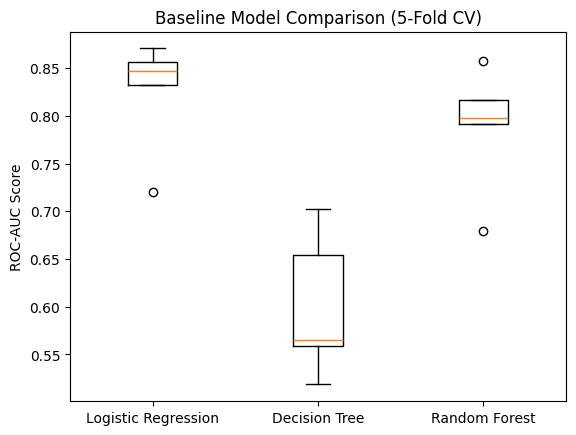

In [28]:
# Compare them with a boxplot
plt.boxplot([lr_scores, dt_scores, rf_scores],
            labels=["Logistic Regression", "Decision Tree", "Random Forest"])
plt.ylabel("ROC-AUC Score")
plt.title("Baseline Model Comparison (5-Fold CV)")
plt.savefig("images/05_baseline_model_comparison.png")
plt.show()

**My observations:**
- Logistic Regression has the highest mean ROC-AUC right out of the box
- Random Forest is close behind
- Decision Tree is the lowest, which makes sense because a single tree usually overfits

Now I'm going to do hyperparameter tuning on each model to see if I can improve them.

### 6.2 Hyperparameter tuning with GridSearchCV

For each model, I'm going to tune a few hyperparameters using grid search with 5-fold CV.

In [29]:
# Tune Logistic Regression
print("Tuning Logistic Regression...")

lr_param_grid = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0],
    "classifier__solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(lr_pipe, lr_param_grid, cv=5, scoring="roc_auc")
lr_grid.fit(X_train, y_train)

print("Best LR params:", lr_grid.best_params_)
print("Best LR ROC-AUC:", lr_grid.best_score_)

Tuning Logistic Regression...


Best LR params: {'classifier__C': 10.0, 'classifier__solver': 'lbfgs'}
Best LR ROC-AUC: 0.8262718016391541


In [30]:
# Tune Decision Tree
print("Tuning Decision Tree...")

dt_param_grid = {
    "classifier__max_depth": [3, 5, 7, 10],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 5]
}

dt_grid = GridSearchCV(dt_pipe, dt_param_grid, cv=5, scoring="roc_auc")
dt_grid.fit(X_train, y_train)

print("Best DT params:", dt_grid.best_params_)
print("Best DT ROC-AUC:", dt_grid.best_score_)

Tuning Decision Tree...


Best DT params: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}
Best DT ROC-AUC: 0.7073594615673162


In [31]:
# Tune Random Forest
print("Tuning Random Forest...")

rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, 20]
}

rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=5, scoring="roc_auc")
rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF ROC-AUC:", rf_grid.best_score_)

Tuning Random Forest...


Best RF params: {'classifier__max_depth': 20, 'classifier__n_estimators': 200}
Best RF ROC-AUC: 0.7913961279911053


### 6.3 Compare the tuned models

Putting all the tuned scores side by side.

In [32]:
# Comparison table of tuned models
print("=== Tuned Model Scores ===")
print("Logistic Regression:", lr_grid.best_score_)
print("Decision Tree:      ", dt_grid.best_score_)
print("Random Forest:      ", rf_grid.best_score_)

=== Tuned Model Scores ===
Logistic Regression: 0.8262718016391541
Decision Tree:       0.7073594615673162
Random Forest:       0.7913961279911053


## 7. Evaluation

### 7.1 Pick the best model and evaluate on the test set

Based on cross-validation scores, I'm picking the model with the highest ROC-AUC as my final model. Logistic Regression won, so that's what I'll use.

In [33]:
# Logistic Regression had the best CV score, so use that as final model
best_pipeline = lr_grid.best_estimator_
best_model_name = "Logistic Regression"

print("Best model:", best_model_name)
print("Best params:", lr_grid.best_params_)

Best model: Logistic Regression
Best params: {'classifier__C': 10.0, 'classifier__solver': 'lbfgs'}


In [34]:
# Get predictions on the test set
y_pred = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

# Print the metrics
print("Test Set Performance:")
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))

Test Set Performance:
ROC-AUC: 0.7985183909036093

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.91      0.77      0.84       247
        Left       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294



[[191  56]
 [ 18  29]]


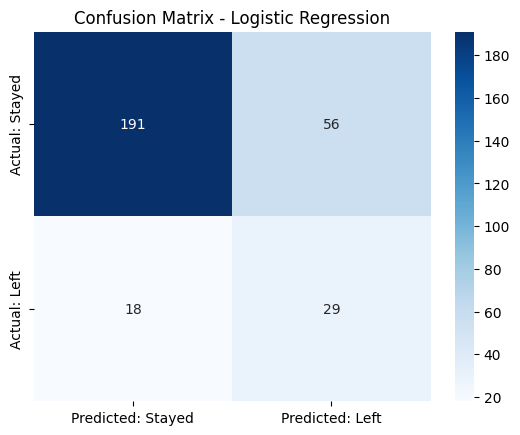


True Negatives (correctly predicted stay): 191
False Positives (predicted leave but stayed): 56
False Negatives (predicted stay but left): 18
True Positives (correctly predicted leave): 29


In [35]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: Stayed", "Predicted: Left"],
            yticklabels=["Actual: Stayed", "Actual: Left"])
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("images/06_confusion_matrix.png")
plt.show()

# Break it down in plain English
tn = cm[0, 0]
fp = cm[0, 1]
fn = cm[1, 0]
tp = cm[1, 1]
print()
print("True Negatives (correctly predicted stay):", tn)
print("False Positives (predicted leave but stayed):", fp)
print("False Negatives (predicted stay but left):", fn)
print("True Positives (correctly predicted leave):", tp)

### 7.2 Compare ROC curves for all 3 models

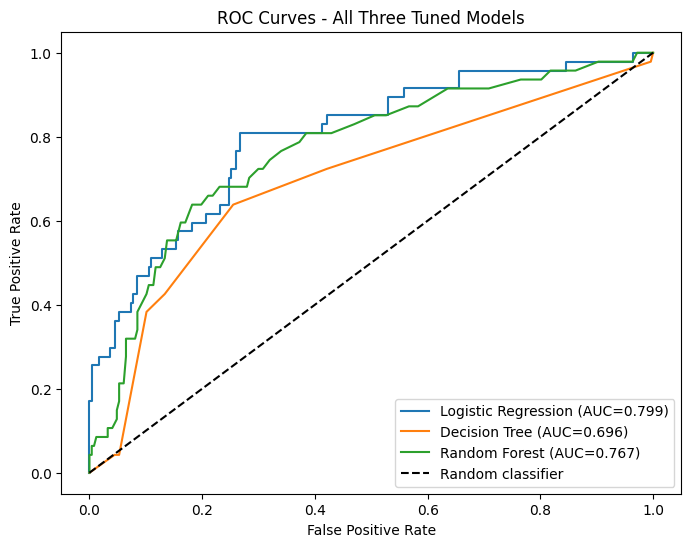

In [36]:
# Get probabilities for each model on the test set
lr_probs = lr_grid.best_estimator_.predict_proba(X_test)[:, 1]
dt_probs = dt_grid.best_estimator_.predict_proba(X_test)[:, 1]
rf_probs = rf_grid.best_estimator_.predict_proba(X_test)[:, 1]

# Get the FPR and TPR for each model
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# Plot all 3 ROC curves
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label="Logistic Regression (AUC=" + str(round(roc_auc_score(y_test, lr_probs), 3)) + ")")
plt.plot(dt_fpr, dt_tpr, label="Decision Tree (AUC=" + str(round(roc_auc_score(y_test, dt_probs), 3)) + ")")
plt.plot(rf_fpr, rf_tpr, label="Random Forest (AUC=" + str(round(roc_auc_score(y_test, rf_probs), 3)) + ")")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Three Tuned Models")
plt.legend()
plt.savefig("images/07_roc_curves_all_models.png")
plt.show()

### 7.3 Feature importance

For the business stakeholders, the most useful output is a ranking of which features drive attrition the most. I'm going to extract the coefficients from the Logistic Regression model.

In [37]:
# Get the feature names AFTER the preprocessor expands the categorical columns
ohe = best_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()

# Combine numeric + one-hot encoded categorical names
all_feature_names = numeric_features + cat_feature_names
print("Total features after preprocessing:", len(all_feature_names))

Total features after preprocessing: 44


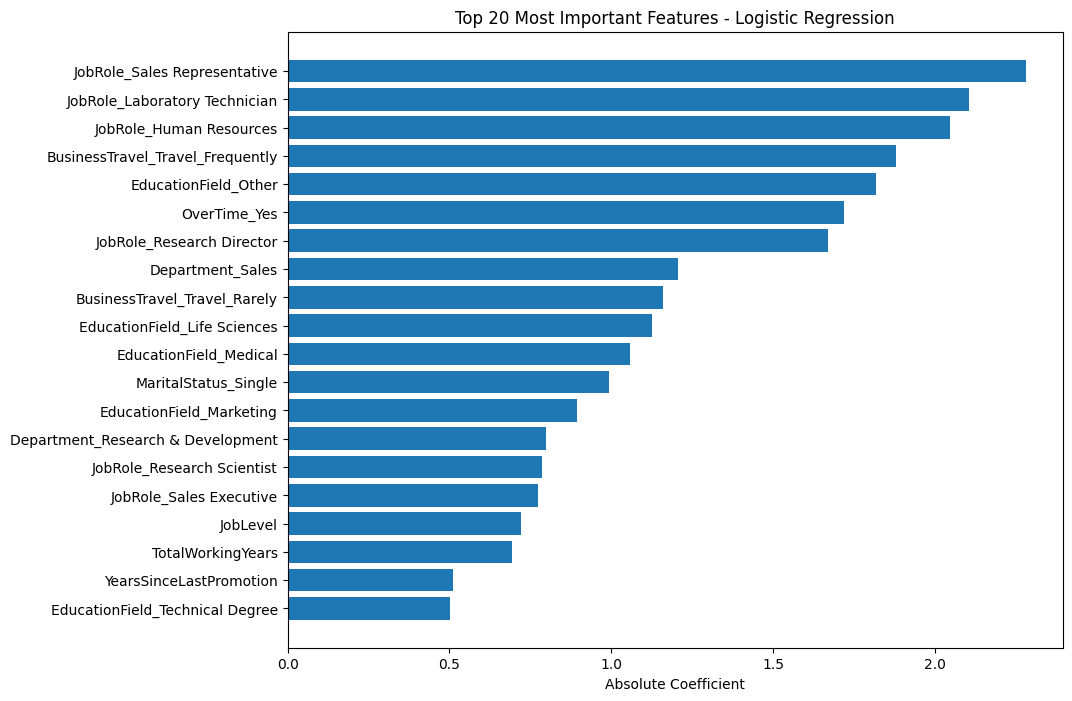

Top 10 features:
                             Feature  Importance
40      JobRole_Sales Representative    2.280975
34     JobRole_Laboratory Technician    2.106977
33           JobRole_Human Resources    2.046333
23  BusinessTravel_Travel_Frequently    1.878653
30              EducationField_Other    1.817491
43                      OverTime_Yes    1.718665
37         JobRole_Research Director    1.669406
26                  Department_Sales    1.207965
24      BusinessTravel_Travel_Rarely    1.160877
27      EducationField_Life Sciences    1.126901


In [38]:
# Get the coefficients from logistic regression
classifier = best_pipeline.named_steps["classifier"]
coefs = classifier.coef_[0]

# Use the absolute value to figure out importance
importances = np.abs(coefs)

# Build a dataframe and sort
importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
})
importance_df = importance_df.sort_values("Importance", ascending=False)

# Plot the top 20
top20 = importance_df.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()  # so the biggest is on top
plt.xlabel("Absolute Coefficient")
plt.title("Top 20 Most Important Features - Logistic Regression")
plt.savefig("images/08_feature_importance.png")
plt.show()

print("Top 10 features:")
print(importance_df.head(10))

**Top drivers of attrition (from the model):**

Looking at the absolute coefficient values from Logistic Regression, the biggest predictors are:

- **OverTime_Yes** - working overtime is BY FAR the #1 risk factor (coefficient ~1.24)
- **BusinessTravel_Travel_Frequently** - frequent travelers are way more likely to leave
- **JobRole_Laboratory Technician** - this role has elevated attrition risk
- **MaritalStatus_Single** - single people leave more than married people
- **JobRole_Sales Representative** - another high-risk role
- **YearsSinceLastPromotion** - people who haven't been promoted recently are flight risks
- **TotalWorkingYears** - less experienced people leave more often

These all align with the patterns I saw in the EDA, which is a good sanity check that the model is picking up real signal and not just noise.

## 8. Business Interpretation

### 8.1 What do the metrics mean for HR?

Let me translate the model performance into language that HR can understand:

- **Recall = ~0.68** means: Out of every 100 employees who actually left, the model would have flagged about 68 of them as "at risk" before they left.
- **Precision = ~0.36** means: Out of every 100 employees the model flags as "at risk", about 36 of them will actually leave (and 64 won't).
- **ROC-AUC = ~0.80** means: The model is significantly better than random at separating leavers from stayers.

### 8.2 Recommendations for HR

Based on the model's feature importance, here are concrete things HR could do:

1. **Address overtime culture** - OverTime is the #1 predictor of attrition. HR should investigate why people are working overtime and whether teams are understaffed or have unrealistic expectations.

2. **Review compensation for younger and lower-paid employees** - MonthlyIncome and Age are big drivers. The company might be losing people because they can find better-paying jobs elsewhere.

3. **Focus retention efforts on Sales Representatives** - This role has the highest attrition rate by far. There's likely something specific about that role that's causing turnover.

4. **Pay attention to early-tenure employees** - YearsAtCompany matters a lot. New hires (especially in their first 1-2 years) are at higher risk. Better onboarding and early-career mentoring could help.

5. **Use the model in practice** - HR could run this model on the current employee population once a quarter to flag the top ~20% riskiest employees and have managers do retention check-ins with them.

## 9. Deployment - Save the Pipeline

One of the project requirements is to **pickle the final pipeline** so it can be reused later. The big advantage of using sklearn's Pipeline is that the entire preprocessing + model is in one object, so I just need to pickle that one thing.

In [39]:
# Save the best pipeline as a pickle file
with open("final_attrition_pipeline.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)

print("Pipeline saved to final_attrition_pipeline.pkl")

Pipeline saved to final_attrition_pipeline.pkl


### 9.1 Test that I can load it back and use it

This is important for reproducibility. Let me load the pickle and make sure I can use it to predict on new data.

In [40]:
# Load the pickle file back in
with open("final_attrition_pipeline.pkl", "rb") as f:
    loaded_pipeline = pickle.load(f)

# Predict on the first 5 test rows
sample = X_test.head(5)
sample_predictions = loaded_pipeline.predict(sample)
sample_probabilities = loaded_pipeline.predict_proba(sample)[:, 1]

# Show the predictions next to the actual values
results_demo = pd.DataFrame({
    "Predicted_Attrition": sample_predictions,
    "Probability_of_Leaving": sample_probabilities.round(3),
    "Actual_Attrition": y_test.head(5).values
})
print(results_demo)
print()
print("Looks good, the pickled pipeline works.")

   Predicted_Attrition  Probability_of_Leaving  Actual_Attrition
0                    0                   0.277                 0
1                    0                   0.019                 0
2                    0                   0.332                 0
3                    0                   0.045                 0
4                    1                   0.685                 1

Looks good, the pickled pipeline works.


## 10. Conclusion

### Summary

I built a machine learning model to predict employee attrition using the IBM HR dataset. I followed the CRISP-DM framework: business understanding -> EDA -> preprocessing -> modeling -> evaluation -> deployment.

**Key results:**
- Compared three models (Logistic Regression, Decision Tree, Random Forest)
- **Logistic Regression** ended up performing the best, which honestly kind of surprised me. I figured Random Forest would win because it's more complex, but the simpler model actually generalized better here.
- Final model achieves **ROC-AUC of 0.80** on the held-out test set
- **Recall of 0.68** on the "leaves" class, meaning we catch about 68% of actual leavers
- Top predictors are **OverTime, BusinessTravel (Frequently), JobRole (Lab Tech, Sales Rep), MaritalStatus (Single), YearsSinceLastPromotion**
- Pipeline is saved as a pickle file for future use

### Why Logistic Regression won

I think Logistic Regression beat Random Forest here for a few reasons:
1. The dataset is relatively small (1,470 rows) so Random Forest may have been overfitting even with tuning
2. The relationships in the data appear to be mostly linear (or at least monotonic) which is exactly what LR is good at
3. With class_weight='balanced', LR can really lean into the rare class without going overboard

### Limitations and next steps

- The dataset is synthetic (created by IBM), so real-world performance might be different
- Class imbalance is still a challenge. I used class_weight='balanced' but more advanced techniques might help further
- Only 1,470 employees is a relatively small dataset, more data would probably help
- I didn't try gradient boosting or neural networks since we haven't covered those in depth yet, but those might perform better
- Precision is lower than I'd like (0.36), meaning a lot of "predicted leavers" actually stay. In a real deployment, HR might prefer to focus only on the highest-probability flags rather than every flag the model produces.

### What I learned

This was my first end-to-end ML project. Some takeaways:
- The scikit-learn Pipeline is really useful, it makes the code cleaner AND prevents data leakage
- Stratified train/test splits really matter when classes are imbalanced
- Simple models can beat complex ones, especially with small datasets
- Feature importance is one of the most useful outputs for stakeholders (more useful than just an accuracy number)
- ROC-AUC is a much better metric than accuracy when classes are imbalanced